In [65]:
import math
from scipy.stats import norm
import qfin as qf
import matplotlib.pyplot as plt
import numpy as np

In [66]:
S, K, T, r, vol, q, option_type = 45, 40, 1, 0.1, 0.2, 0.01, "Call"
parameters = dict(S=S, K=K, T=T, r=r, vol=vol, q=q, option_type = option_type)

In [67]:
def black_scholes(S, K, T, r, vol, q=0, option_type="Call"):
    # S - current price
    # K - strike price
    # T - Time to expiry (years)
    # r - risk-free rate
    # vol - volatility
    # q - dividend yield (0 = no dividends)

    d1 = (math.log(S/K) + (r - q + 0.5 * vol**2)*T) / (vol * math.sqrt(T))

    d2 = d1 - (vol * math.sqrt(T))

    # Call option price

    call = S * norm.cdf(d1) * math.exp(-q*T) - K * \
        math.exp(-r*T) * norm.cdf(d2)

    # Put option price

    put = K * math.exp(-r*T) * norm.cdf(-d2) - S * \
        norm.cdf(-d1) * math.exp(-q*T)

    if option_type == "Call":
        return call
    else:
        return put

In [ ]:
def calculate_net(path, K, premium, option_type):
    if option_type == "Call":
        pay = max(path.simulated_path[-1] - K, 0)
    else:
        pay = max(K - path.simulated_path[-1], 0)
    pay *= math.exp(-r*T)   # bring payoff back to present value
    return pay - premium


In [69]:
def black_scholes_plot(S, K, T, r, vol, q, option_type):

    premium = black_scholes(S, K, T, r, vol, q, option_type)
    path = qf.simulations.GeometricBrownianMotion(S, r, vol, 1/252, T)
    net = calculate_net(path, K, premium, option_type)

    plt.style.use('dark_background')
    plt.hlines(K, 0, T * 252, label="Strike", color="Blue")
    plt.plot(path.simulated_path, label="Price Path", color="White")

    colour = 'green' if net > 0 else 'red'
    plt.vlines(T * 252, min(K, path.simulated_path[-1]), max(K, path.simulated_path[-1]),
               color=colour, label="P/L")
    print(f"{'Loss' if net < 0 else 'Win' if net > 0 else 'Breakeven'} of {round(abs(net), 2)}")

    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()


Win of 9.95


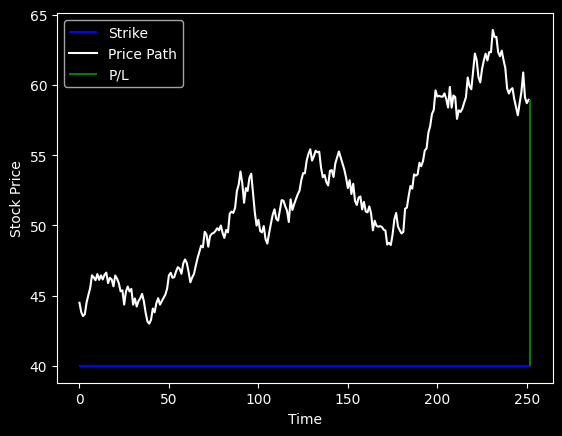

In [70]:
black_scholes_plot(**parameters)

In [71]:
premium = black_scholes(S, K, T, r, vol, q, option_type)
print(f"{option_type} price is {premium}")
print(f"Market quote: 8.41 @ 8.73") # Example market quote for demo purposes
print(f"Edge: {premium - 8.53}")

Call price is 8.977743233509386
Market quote: 8.41 @ 8.73
Edge: 0.44774323350938694


In [72]:
pnl = []
for i in range(100000):
    path = qf.simulations.GeometricBrownianMotion(S, r, vol, 1/252, T)  # New path each time
    pnl.append(calculate_net(path, K, premium, option_type))
print(f"Mean P/L: {round(np.mean(pnl),2)}")

    


Mean P/L: 1.36
